グレースケール画像の2次元DFTを計算し，```np.fft.fftshift``` を適用した振幅スペクトルを表示しなさい．
ただし，振幅スペクトルはダイナミックレンジが非常に広いため，
$20 \log_{10}(|X[k_1, k_2]| + \varepsilon)$（$\varepsilon$ は小さな正の数，例えば $10^{-9}$）のように対数スケールに変換して表示すること．
画像の滑らかな変化（低周波成分）と細かい模様やエッジ（高周波成分）が，
スペクトル上のどこに対応するか考察しなさい．

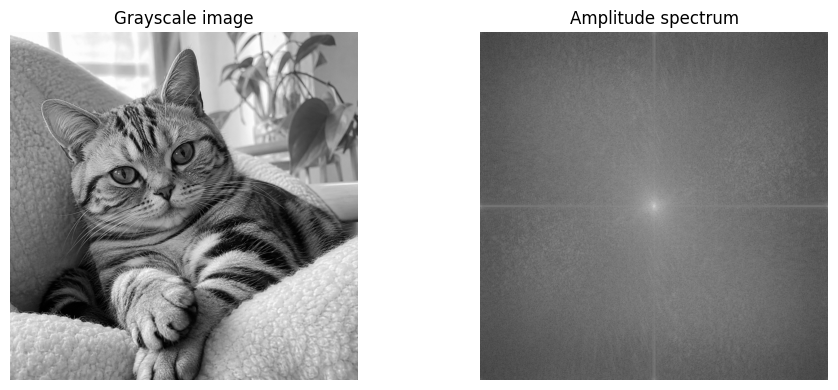

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 入力画像パス
input_path = "/home/syamashita/initial-training-2026/syamashita-tu/chapter12/cat.png"

# 小さな正の数
epsilon = 1e-9

# Pillowでグレースケール画像として読み込み
img = Image.open(input_path).convert("L")

# NumPy配列へ変換
f = np.asarray(img, dtype=np.float64)

# 2次元DFT
X = np.fft.fft2(f)

# 直流成分を中心へ移動
X_shift = np.fft.fftshift(X)

# 対数スケールの振幅スペクトル
amp_db = 20 * np.log10(np.abs(X_shift) + epsilon)

# 表示
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(f, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(amp_db, cmap="gray")
plt.title("Amplitude spectrum")
plt.axis("off")

plt.tight_layout()
plt.show()

画像中の滑らかな明るさ変化や大まかな構造は，空間的にゆっくり変化するため低周波成分に対応する．したがって， fftshift 後の振幅スペクトルでは中心付近に強く現れやすい．

一方，細かい模様，急な明暗変化，物体の輪郭やエッジは，空間的に急激に変化するため高周波成分に対応する．したがって，振幅スペクトルでは中心から離れた位置に現れやすい．

画像に周期的な縞模様が含まれる場合，その周期に対応する周波数位置に明るい点や線状のピークが現れることがある．エッジが多い画像では，高周波領域にも比較的強い成分が広がる傾向がある．